# Fast Food Promotion A/B Test + Randomization Deep Dive

This notebook analyses the results of an A/B test run across hundreds of fast food stores to determine which of three promotional campaigns drives the highest weekly sales. Each store was randomly assigned to exactly one promotion and tracked over 4 weeks.

**The core question**: is there a statistically significant difference in sales across the three promotions, and if so, which one should be rolled out?

**Approach**:
1. **Experiment validity** — verify randomization quality, covariate balance, and check for sample ratio mismatch
2. **Exploratory analysis** — inspect sales distributions by promotion and market size
3. **Statistical testing** — Kruskal-Wallis with Dunn's post-hoc (Holm correction), backed by ANOVA assumption checks
4. **Subgroup analysis** — test whether the promotion effect varies by market size

In [ ]:
import os
import dotenv
import kagglehub
import pandas as pd
import shutil
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from statsmodels.graphics.mosaicplot import mosaic
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import chisquare, chi2_contingency,\
    shapiro, probplot, levene, kruskal, bootstrap
import scikit_posthocs as sp

In [ ]:
def read_data():
    data_dir = "./data"
    os.makedirs(data_dir, exist_ok = True)
    try:
        data = pd.read_csv(f"{data_dir}/fast_food_marketing_campaign_ab_test.csv")
    except FileNotFoundError:
        # Download from Kaggle and save to data directory
        dotenv.load_dotenv(dotenv.find_dotenv())
        kagglehub.login()
        kagglehub.dataset_download("chebotinaa/fast-food-marketing-campaign-ab-test",
                                   output_dir = data_dir,
                                   force_download = True)
        data = pd.read_csv(f"{data_dir}/WA_Marketing-Campaign.csv")
        data.to_csv(f"{data_dir}/fast_food_marketing_campaign_ab_test.csv", index = False)
        
        # # Clean up downloaded files
        base_dir = Path.cwd().resolve().parent / "ab_testing/data"
        print(base_dir)
        targets = [base_dir / "WA_Marketing-Campaign.csv", base_dir / ".complete"]

        for target in targets:
            if target.is_dir():
                shutil.rmtree(target)
            elif target.exists():
                target.unlink()
            else:
                print(f"Not found: {target}")
    data.columns = data.columns.str.lower()
    data["promotion"] = data["promotion"].astype(str)
    data["market_location_id"] = data["marketid"].astype(str) + "-" + data["locationid"].astype(str)
    return data

data = read_data()

## 0. Initial checks

Before diving into the analysis, a few sanity checks to confirm the data is in the expected shape:

- **No missing values** anywhere in the dataset
- **Location IDs are globally unique**: the same `locationid` does not repeat across different markets
- **Consistent time coverage**: every location has exactly 4 weeks of data
- **Clean group assignment**: no store participates in more than one promotion group

In [3]:
# Missing values, uniqueness of location IDs, and consistency of timeframes
print(f"Are there null values in the dataset? --> {data.isnull().sum().any()}")
print("Independently of the market, is the location ID unique? --> "\
      f"{len(data['market_location_id'].unique()) == len(data['locationid'].unique())}")
print("Do all locations have the same timeframe? (4 weeks) --> "\
      f"{(data.groupby("market_location_id")["promotion"].size() == 4).all()}")

# Checking if there are stores that appear in multiple groups
which_in_both = data.groupby("market_location_id")["promotion"].nunique().gt(1)
which_in_both = which_in_both[which_in_both].index.tolist()
total_users = data["market_location_id"].nunique()
print("\nStores in multiple groups VS total: "\
      f"{len(which_in_both)} / {total_users} ({len(which_in_both) / total_users:.2%})")
print("Stores participating in each promotion: "\
      f"{data.groupby('promotion')['market_location_id'].nunique().to_dict()}")
print("Markets participating in each promotion: "\
      f"{data.groupby(['promotion'])['marketid'].nunique().to_dict()}")

Are there null values in the dataset? --> False
Independently of the market, is the location ID unique? --> True
Do all locations have the same timeframe? (4 weeks) --> True

Stores in multiple groups VS total: 0 / 137 (0.00%)
Stores participating in each promotion: {'1': 43, '2': 47, '3': 47}
Markets participating in each promotion: {'1': 10, '2': 9, '3': 10}


Store and market counts are close but not perfectly balanced: **43 / 47 / 47** stores and **10 / 9 / 10** markets per promotion. Promotion 2 covers one fewer market — something we'll revisit shortly.

## 1. Randomization Unit Deep Dive
To understand *how* the randomization was structured, we look at the joint distribution of stores across markets and promotions with a mosaic plot:

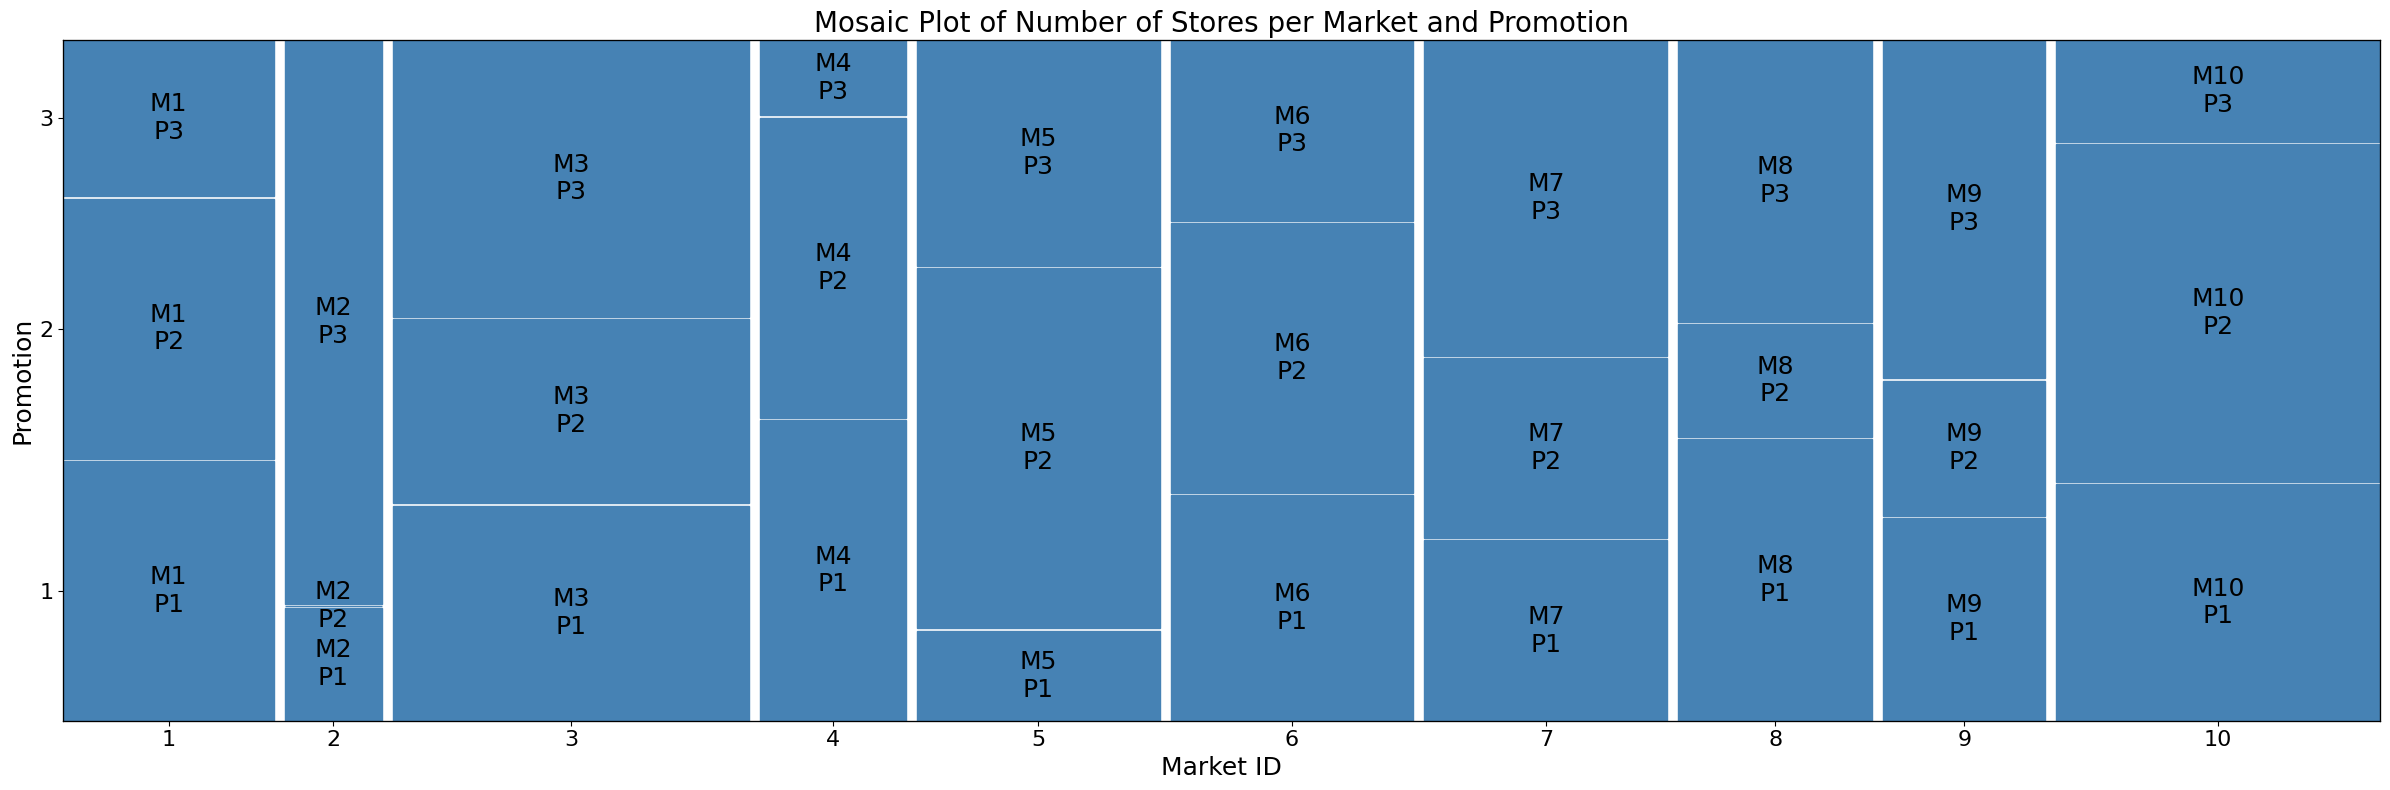

In [4]:
# Prepare data for mosaic plot
mosaic_data = data.groupby(["marketid", "promotion"])["locationid"].nunique().reset_index()
mosaic_data.columns = ["marketid", "promotion", "num_stores"]
mosaic_data = mosaic_data.pivot(index = "marketid", columns = "promotion", values = "num_stores").fillna(0)

# Create mosaic plot
fig, ax = plt.subplots(figsize = (24, 8))
mosaic(
    mosaic_data.stack(),
    ax = ax,
    labelizer = lambda k: f"M{k[0]}\nP{k[1]}",
    properties = lambda k: {"color": "steelblue"},
)
for text in ax.texts:
    text.set_fontsize(18)
ax.set_xlabel("Market ID", fontsize = 18)
ax.set_ylabel("Promotion", fontsize = 18)

ax.set_title("Mosaic Plot of Number of Stores per Market and Promotion", fontsize = 20)
ax.tick_params(axis = "both", labelsize = 16)
plt.tight_layout()
plt.show()

The mosaic plot reveals two things:

- **Market size varies significantly** (tile *width* = share of total stores per market). Market 3 is the largest with 22 stores; market 2 is the smallest with only 6.
- **Within each market, stores are unevenly split across promotions** (tile *height* = conditional distribution given the market). Market 1 is the most balanced (5 / 5 / 3); markets 2 and 5 show the strongest imbalance — most notably, market 2 has **zero stores assigned to promotion 2**.

This uneven within-market allocation confirms that **randomization was done at the store (location) level**, not at the market level. It also explains why promotion 2 reaches only 9 out of 10 markets: during randomization, market 2 happened to receive no stores under that promotion.

A natural improvement would be **stratified randomization by market**: randomize store assignments *within* each market to guarantee a roughly equal split across every stratum. Without it, a larger market can end up over-represented in one promotion which, if markets differ systematically in baseline sales, could bias the overall comparison.

### 1.1. Analysis on probable intoxication due to chosen randomization
Without pre-experiment data we can't observe true baselines. As a rough proxy, we average per-store weekly sales across all promotions within each market. The caveat: since interventions are already running, this blends all promotion effects.

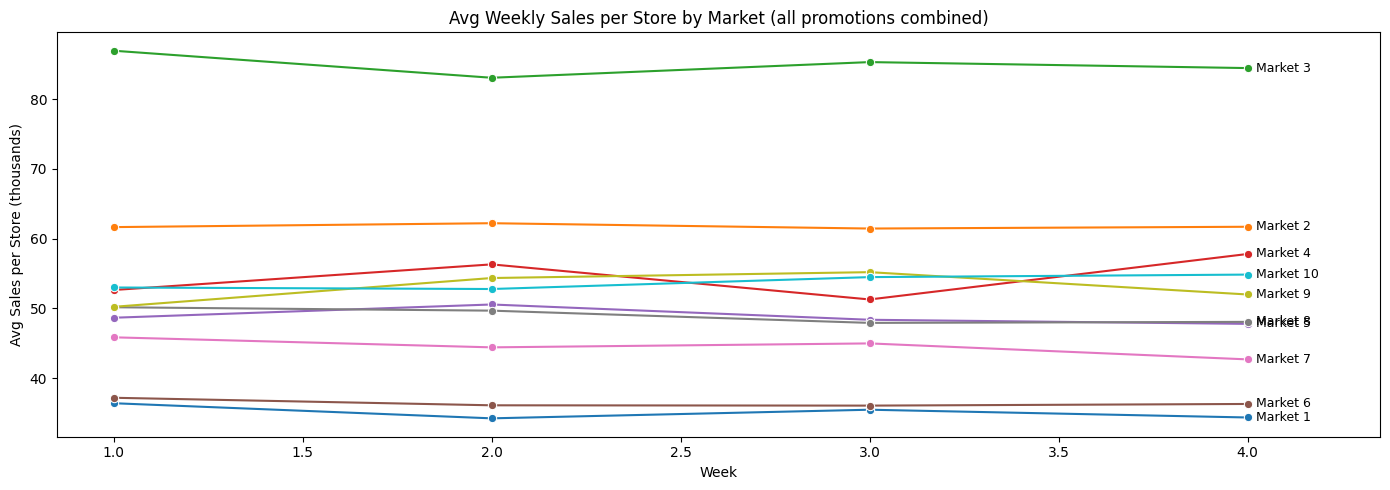

In [5]:
market_weekly_avg = data.groupby(["marketid", "week"])["salesinthousands"].mean().reset_index()

fig, ax = plt.subplots(figsize = (14, 5))
sns.lineplot(
    data = market_weekly_avg, x = "week", y = "salesinthousands",
    hue = "marketid", marker = "o", ax = ax, legend = False,
    palette = sns.color_palette("tab10", n_colors = market_weekly_avg["marketid"].nunique()),
)

for market_id, group in market_weekly_avg.groupby("marketid"):
    last = group.loc[group["week"].idxmax()]
    ax.annotate(
        f"Market {int(market_id)}",
        xy = (last["week"], last["salesinthousands"]),
        xytext = (6, 0),
        textcoords = "offset points",
        va = "center",
        fontsize = 9,
    )

ax.set_xlim(right = ax.get_xlim()[1] + 0.2)
ax.set_title("Avg Weekly Sales per Store by Market (all promotions combined)")
ax.set_xlabel("Week")
ax.set_ylabel("Avg Sales per Store (thousands)")
plt.tight_layout()
plt.show()

In [6]:
data[["marketid", "marketsize"]].drop_duplicates().to_dict(orient = "records")

[{'marketid': 1, 'marketsize': 'Medium'},
 {'marketid': 2, 'marketsize': 'Small'},
 {'marketid': 3, 'marketsize': 'Large'},
 {'marketid': 4, 'marketsize': 'Small'},
 {'marketid': 5, 'marketsize': 'Medium'},
 {'marketid': 6, 'marketsize': 'Medium'},
 {'marketid': 7, 'marketsize': 'Medium'},
 {'marketid': 8, 'marketsize': 'Medium'},
 {'marketid': 9, 'marketsize': 'Medium'},
 {'marketid': 10, 'marketsize': 'Large'}]

A couple of things stand out:

- **Market 3 (Large)** has the highest per-store sales, consistent with the expectation that a larger geographic market brings more footfall and revenue.
- **Market 2 (Small)** comes in second, which seems counterintuitive at first. One plausible explanation: in a small market with limited competition, a chain can capture a disproportionate share of local demand — effectively acting as the dominant (or only) fast food option in the area, which would drive unusually high per-store volume. Worth keeping in mind that market 2 only has 6 stores, so its average is also noisier than the rest.

Setting the promotion-contamination caveat aside, the visible spread across markets is meaningful on its own: if markets with systematically higher per-store sales are over-represented in one promotion group, the comparison is unfair regardless of which promotion is "better". This is the practical argument for stratifying randomization by market — not just to balance store counts, but to balance market-level sales potential across groups.

The second chart breaks the same metric down by promotion within each market — this is where the stratification risk becomes concrete. If markets with systematically higher (or lower) sales are over-represented in a specific promotion, the group averages are not comparing like for like.

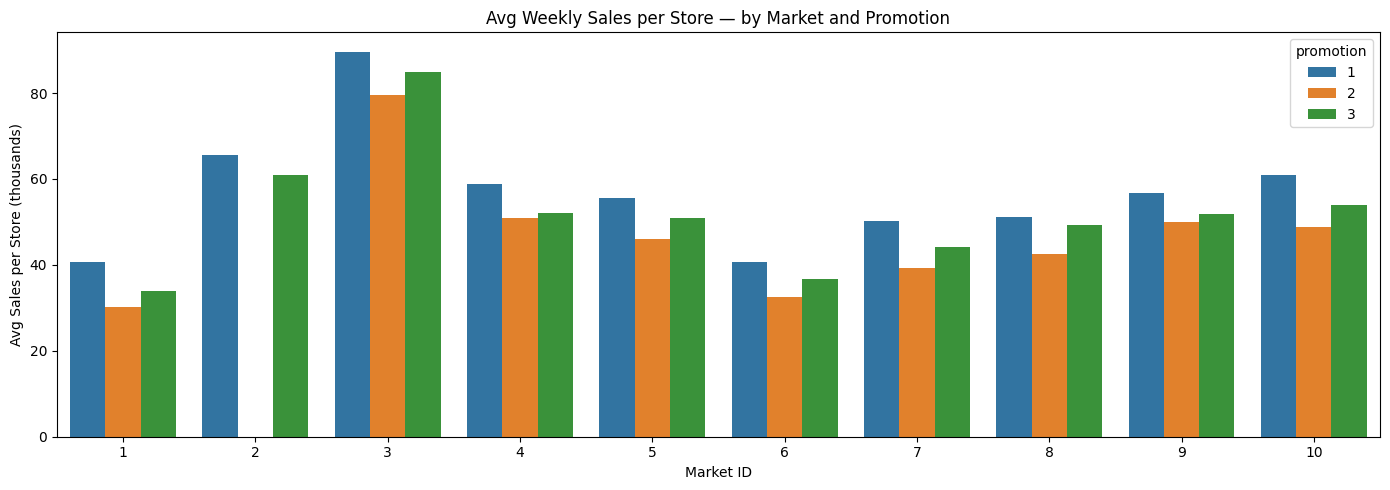

In [7]:
# Average weekly sales per store, by market and promotion
# (each row in `data` is already one store × one week, so .mean() gives per-store average)
market_promo_avg = data.groupby(["marketid", "promotion"])["salesinthousands"].mean().reset_index()
market_promo_avg["promotion"] = market_promo_avg["promotion"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data = market_promo_avg, x = "marketid", y = "salesinthousands", hue = "promotion",
            ax = ax)
ax.set_title("Avg Weekly Sales per Store — by Market and Promotion")
ax.set_xlabel("Market ID")
ax.set_ylabel("Avg Sales per Store (thousands)")
plt.tight_layout()
plt.show()

A few observations from the chart:

- **Promotion 1 tends to rank highest across all markets**, followed by promotion 3 and then promotion 2. The ordering is consistent even if the proportional gaps vary — compare markets 4 and 5 on promotions 2 and 3, for instance.
- The formal term for what we're checking here is the absence of a **market × promotion interaction**: if the promotion ranking holds regardless of which market we look at, it means the effect of a promotion doesn't depend on the market it lands in.

**What this implies for the randomization choice:**

The consistency of the ordering is retrospective evidence that the no-interaction assumption holds. Store-level randomization without market stratification is only "safe" under that assumption — if promotion effects were market-dependent (e.g., promotion 1 works well in large markets but poorly in small ones), an unbalanced market-promotion assignment would introduce directional bias. Since the ordering appears stable, the risk is lower.

That said, two caveats:

- **Magnitude can still be distorted**: even without a directional flip, markets with more stores dominating a specific promotion inflate that promotion's aggregate average through composition, not through a genuine promotion effect. The winner is likely the same, but the margin may be off.
- **This is a post-hoc validation on contaminated data**: what the chart shows is `market baseline + promotion effect`. The consistent ordering could reflect "promotion 1 is genuinely better everywhere" or partially reflect market composition from the randomization itself. Without pre-experiment data we can't fully separate the two.

We can conclude that the experimenter likely designed the experiment assuming no market × promotion interaction — implicitly or explicitly. The data appears to support that assumption, which retrospectively justifies the store-level randomization. It was still a design risk, though, and one that stratified randomization would have eliminated upfront.

In [8]:
data_aggregated = data.groupby(["marketid", "marketsize", "locationid", "ageofstore",
                                "promotion"])["salesinthousands"].mean().reset_index()

### 1.2. Randomization quality - additional analyses
Covariate balance checks using *marketsize* and *ageofstore* against *promotion* will be performed as a proxy for randomization quality. Imbalanced covariates - for instance, it is seen that promotion 1 consistently falls under older stores (which might relate to more revenue) - are confounds that we can't fully adjust for.

In [9]:
data_aggregated.groupby(["promotion"])["ageofstore"].describe()

,count,mean,std,min,25%,50%,75%,max
promotion,,,,,,,,
1,43.0,8.279070,6.695150,1.0,3.0,6.0,12.0,27.0
2,47.0,7.978723,6.651216,1.0,3.0,7.0,10.0,28.0
3,47.0,9.234043,6.705652,1.0,5.0,8.0,11.5,24.0


For *ageofstore* the means (8.3 / 8.0 / 9.2) with std ~6.7 are close enough that the difference is well within noise.  
As for *marketsize*, there is no significance of its association with the *promotion* column, when checking the outcome of the Chi-Square test of independence.

In [10]:
_, p_value, _, _ = chi2_contingency(
    pd.crosstab(data_aggregated["promotion"], data_aggregated["marketsize"])
)
print(f"Chi-squared test p-value for promotion vs. market size: {p_value:.4f}")

Chi-squared test p-value for promotion vs. market size: 0.8800


## 2. Sample Ratio Mismatch

Having addressed the concerns over the randomization technique, we now check whether the number of stores assigned to each promotion is roughly what we'd expect under a fair random split.

There is a slight imbalance (**43 / 47 / 47** stores per promotion) so we run a chi-square goodness-of-fit test against the uniform expectation (~45.7 stores each). This is the **Sample Ratio Mismatch (SRM)** check, and it matters because:

- A significant imbalance would suggest the assignment process was not truly random — some systematic force skewed which stores ended up in which group.
- If assignment was non-random, the groups likely differ on pre-existing characteristics beyond the promotion itself (e.g., store size, location, age). Any observed sales difference would then be partly driven by those confounding differences rather than by the promotions.
- In short: SRM doesn't just mean "the groups are unequal in size" — it means **the experiment's internal validity is in question**, because we can no longer assume the groups are exchangeable.

A conservative threshold of `alpha = 0.001` is standard for SRM checks: since this is a guardrail test (not a primary hypothesis), we want to avoid flagging a valid experiment as broken due to random noise.

In [11]:
def sample_ratio_mismatch_test(data, group_col, id_col, alpha = 0.001):
    observed = data.groupby(group_col)[id_col].nunique().tolist()
    expected = [sum(observed) / len(observed)] * len(observed)
    _, p_value = chisquare(f_obs = observed, f_exp = expected)
    if p_value < alpha:
        print(f"The groups are not equally distributed (p = {p_value:.4f} < {alpha})")
    else:
        print(f"The groups are equally distributed (p = {p_value:.4f} >= {alpha})")
    return p_value

srm_alpha = 0.001
p_value = sample_ratio_mismatch_test(data_aggregated, "promotion", "locationid",
                                     alpha = srm_alpha)

The groups are equally distributed (p = 0.8898 >= 0.001)


## 3. Analysis

This data has already been analysed on a temporal basis, and also split by other variables of interest. Let's end up checking the univariate distributions of avg sales, also split by marketsize.

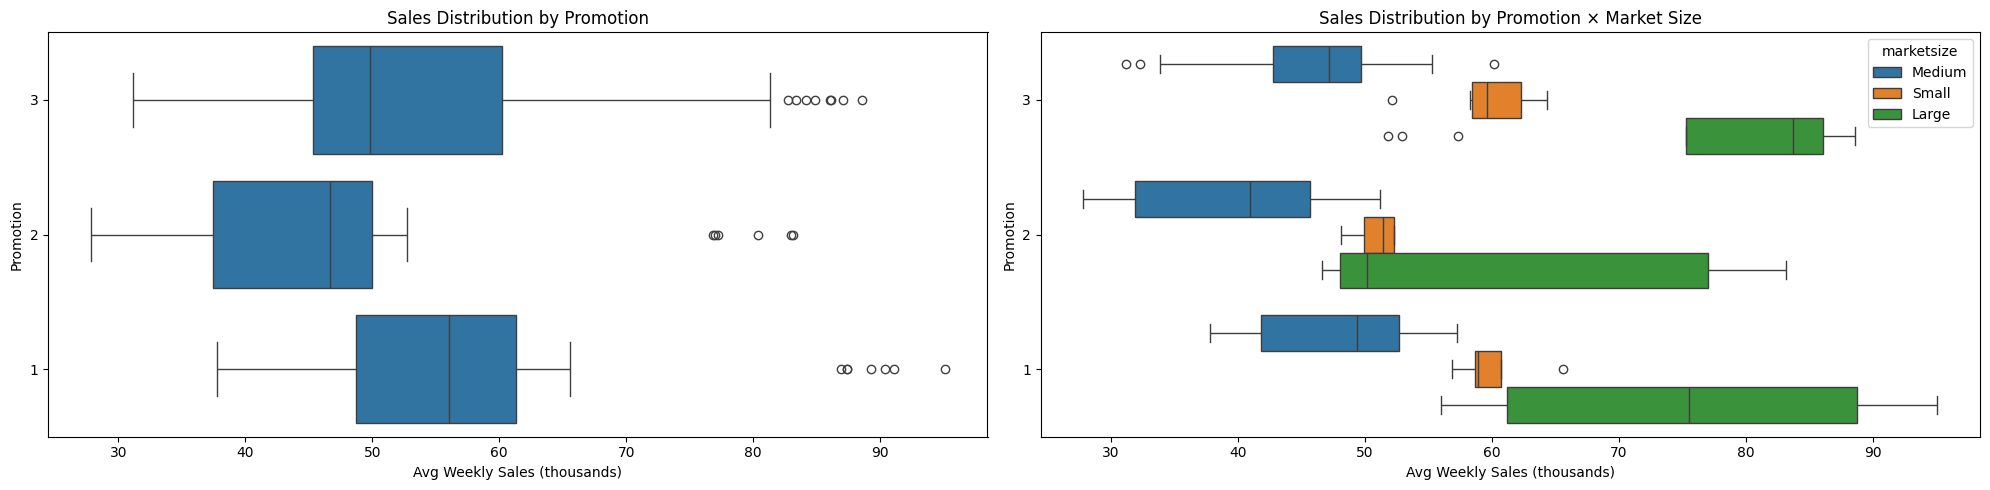

In [12]:
fig, axes = plt.subplots(1, 2, figsize = (20, 5))

sns.boxplot(data = data_aggregated, x = "salesinthousands", y = "promotion", ax = axes[0])
axes[0].set_title("Sales Distribution by Promotion")
axes[0].set_xlabel("Avg Weekly Sales (thousands)")
axes[0].set_ylabel("Promotion")

sns.boxplot(data = data_aggregated, x = "salesinthousands", y = "promotion", hue = "marketsize",
            ax = axes[1])
axes[1].set_title("Sales Distribution by Promotion × Market Size")
axes[1].set_xlabel("Avg Weekly Sales (thousands)")
axes[1].set_ylabel("Promotion")

plt.tight_layout()
plt.show()

# data_aggregated[data_aggregated["salesinthousands"] > 90]

A few things stand out from the plots:

**Overall distribution (left)**: promotion 2 sits visibly lower than promotions 1 and 3, which overlap substantially. Promotion 1 shows a handful of extreme values above 90k — these belong to three stores in market 3 (Large), the highest-sales market in the dataset. Without them, the gap between promotions 1 and 3 would be even narrower.

**Market size breakdown (right)**: the Large segment drives most of the spread. Promotion 1's outliers are entirely concentrated there, inflating its overall mean. Within the Medium segment — which contains the majority of stores — promotions 1 and 3 are very close, and promotion 2 again lags behind. The Small segment has too few stores to draw reliable conclusions from the visual alone.

This already hints at the statistical result: promotion 2 is the clear loser, while 1 and 3 are competitive everywhere.

## 4. Statistical tests

### 4.1 ANOVA's assumptions

In order to look for statistically significant differences within the different applied promotions, a statistical test like ANOVA can be applied. Given this use case, for the initial definition (mean sales overall) we attempt to spot if the average of the mean sales is the same across promotions (null hypothesis) or either one of them is different (alternate hyptothesis). More formally:
- **H₀**: μ₁ = μ₂ = μ₃ — the mean weekly sales per store are equal across all three promotions
- **H₁**: μᵢ ≠ μⱼ for at least one pair *i, j* — at least one promotion has a different mean

ANOVA takes 3 assumptions in the underlying data distribution: normality, independence and homoscedascity. These will be tested in the upcoming cells.

#### 4.1.1. Normality

Q-Q plots compare each group's distribution against a theoretical normal. The Shapiro-Wilk p-value in each title is a formal test of normality — a low p-value (< 0.05) indicates significant departure from normality.

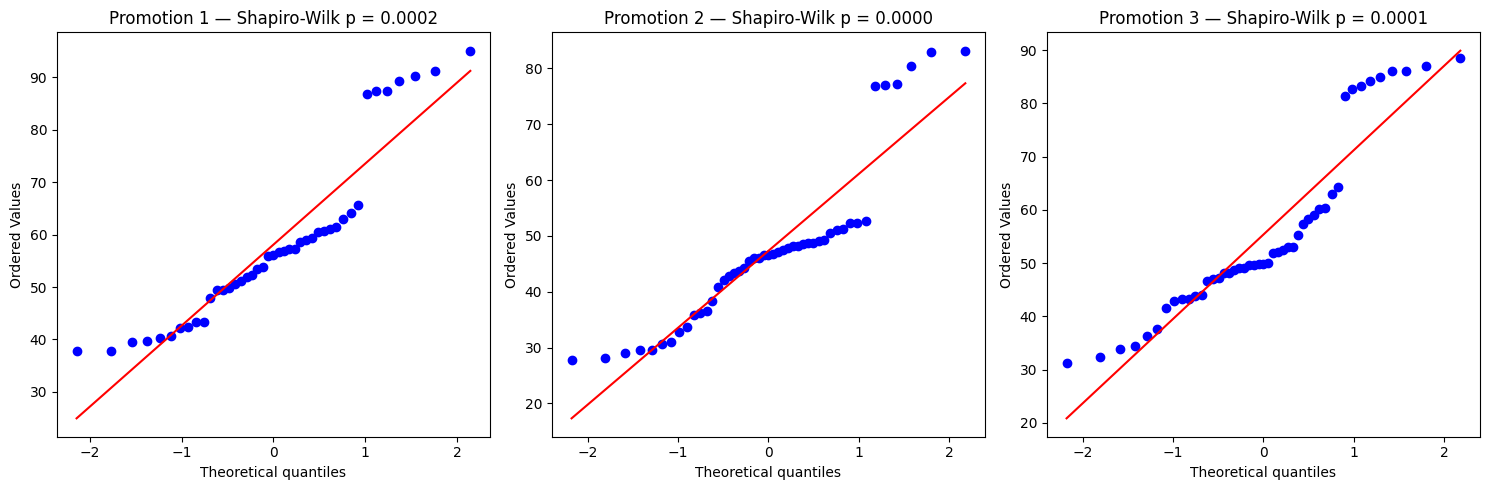

In [14]:
promotions = sorted(data_aggregated["promotion"].unique())
fig, axes = plt.subplots(1, len(promotions), figsize=(15, 5))

for ax, promo in zip(axes, promotions):
    subset = data_aggregated[data_aggregated["promotion"] == promo]["salesinthousands"]
    _, p = shapiro(subset)
    probplot(subset, plot = ax)
    ax.set_title(f"Promotion {promo} — Shapiro-Wilk p = {p:.4f}")

plt.tight_layout()
plt.show()

#### 4.1.2 Independence

Since we aggregated to one row per store (mean weekly sales across the 4 weeks), each observation is an independent unit by construction — one store, one data point, no repeated measurements. Had we used the raw week-level data, observations within the same store would be correlated (the same store's week 1 and week 2 are not independent), violating this assumption and requiring a repeated-measures approach instead.

#### 4.1.3. Homoscedasticity

Levene's test checks whether the variance in sales is equal across the three promotion groups. This is required for the F-statistic in ANOVA to be valid.

In [15]:
groups = [g["salesinthousands"].values for _, g in data_aggregated.groupby("promotion")]
stat, p = levene(*groups)
print(f"Levene's test: statistic = {stat:.4f}, p = {p:.4f}")
if p < 0.05:
    print("Significant difference in variances across groups — homoscedasticity assumption violated.")
else:
    print("No significant difference in variances — homoscedasticity assumption holds.")

Levene's test: statistic = 0.4682, p = 0.6272
No significant difference in variances — homoscedasticity assumption holds.


### 4.2 Kruskal-Wallis test + post-hoc

Non-parametric test comparing rank distributions across the three groups. Preferred here given the normality violations and outliers in promotion 1.

In [16]:
groups = [g["salesinthousands"].values for _, g in data_aggregated.groupby("promotion")]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis: H = {stat:.4f}, p = {p:.4f}")
if p < 0.05:
    print("Significant difference across promotion groups.")
else:
    print("No significant difference across promotion groups.")

Kruskal-Wallis: H = 17.3274, p = 0.0002
Significant difference across promotion groups.


Following up the significant Kruskal-Wallis result are the pairwise comparisons. The appropriate test here is Dunn's post-hoc with Holm correction, which controls the family-wise error rate across the 3 comparisons (1v2, 1v3, 2v3).

In [17]:
dunn = sp.posthoc_dunn(data_aggregated, val_col = "salesinthousands", group_col = "promotion",
                       p_adjust = "holm")
print(dunn[dunn < 0.05])

         1         2         3
1      NaN  0.000170       NaN
2  0.00017       NaN  0.007716
3      NaN  0.007716       NaN


It can be seen that all promotions show significant differences againts promotion 2. Given the previous plots, it is clear that this particular promotion is underperforming compared to the others. As for the pair 1 and 3, there is no significant difference.

To quantify the magnitude of the differences, we compute 95% bootstrap confidence intervals for the mean of each group. Overlapping CIs between promotions 1 and 3 will visually confirm the tie; the gap with promotion 2 shows the practical size of the effect.

> **Note**: overlapping individual CIs do not imply non-significance — that logic only runs one way (non-overlapping guarantees significance, but overlap does not guarantee the opposite). These CIs are for descriptive purposes only; significance is determined by the Dunn's test above.

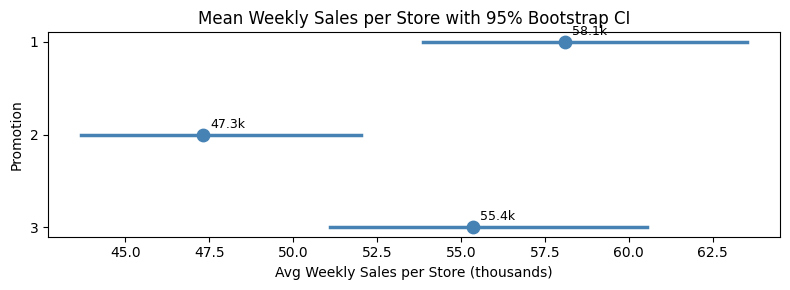

promotion      mean    ci_low   ci_high
        1 58.099012 53.866692 63.519277
        2 47.329415 43.691465 52.033550
        3 55.364468 51.112530 60.549433


In [ ]:
rows = []
for promo, group in data_aggregated.groupby("promotion"):
    sales = group["salesinthousands"].values
    res = bootstrap((sales,), np.mean, confidence_level = 0.95, n_resamples = 9999,
                    random_state = 42)
    rows.append({
        "promotion": promo,
        "mean": sales.mean(),
        "ci_low": res.confidence_interval.low,
        "ci_high": res.confidence_interval.high,
    })

ci_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 3))
for _, row in ci_df.iterrows():
    ax.plot([row["ci_low"], row["ci_high"]], [row["promotion"], row["promotion"]],
            color="steelblue", linewidth=2.5)
    ax.scatter(row["mean"], row["promotion"], color = "steelblue", s = 80, zorder = 5)
    ax.annotate(f'{row["mean"]:.1f}k', xy = (row["mean"], row["promotion"]),
                xytext=(5, 5), textcoords="offset points", fontsize = 9)

ax.set_xlabel("Avg Weekly Sales per Store (thousands)")
ax.set_ylabel("Promotion")
ax.set_title("Mean Weekly Sales per Store with 95% Bootstrap CI")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4.3. Subgroup analysis — promotion × market size interaction

Promotions 1 and 3 are statistically tied overall. To check whether one outperforms the other within specific market size segments, we fit a two-way ANOVA with an interaction term.

The key row is `C(promotion):C(marketsize)` — a significant p-value there means the promotion effect depends on market size, warranting subgroup analysis. If not significant, the overall result holds uniformly across segments.

Note: this switches back to a parametric test. A non-parametric equivalent for factorial designs with interactions is not readily available in Python. The two-way ANOVA is used here pragmatically, supported by the CLT argument for the larger market size cells.

In [ ]:
data_1_3 = data_aggregated[data_aggregated["promotion"].isin(["1", "3"])]
model = smf.ols("salesinthousands ~ C(promotion) * C(marketsize)", data=data_1_3).fit()
sm.stats.anova_lm(model, typ = 2)

Since the interaction row shows a p-value higher than our considered alpha, we fail to confirm an existing interaction promotion x marketsize.

## 5. Conclusions

**Experiment validity**: randomization quality checks passed. Group sizes (43/47/47) show no sample ratio mismatch (p=0.89), and covariates are balanced across groups — marketsize (χ² p=0.88) and store age (means ~8–9 years, std ~6.7) do not differ significantly across promotions. The main design caveat is that randomization was done at the store level without market stratification, which could distort effect magnitudes if market-level sales potential is unevenly distributed across groups. Post-hoc analysis suggests the promotion ordering is consistent across markets, limiting the practical impact of this concern.

**Test results**: both Kruskal-Wallis (H=17.33, p=0.0002) and one-way ANOVA (F=5.85, p=0.0037) agree that at least one promotion group has significantly different sales. Dunn's post-hoc test with Holm correction identifies where the differences lie:

| Pair | Adjusted p-value | Significant? |
|------|-----------------|--------------|
| 1 vs 2 | 0.0002 | Yes |
| 2 vs 3 | 0.0077 | Yes |
| 1 vs 3 | 0.2295 | No |

**Subgroup analysis**: a two-way ANOVA on promotions 1 and 3 across market size segments shows no significant promotion × marketsize interaction (p > 0.05), confirming that the tie between them holds uniformly — neither outperforms the other in any particular market size segment.

**Recommendation**: promotions 1 and 3 are statistically indistinguishable both overall and within every market size segment, but both significantly outperform promotion 2. The data is exhausted on this question — the final choice between promotions 1 and 3 should be driven by factors outside the dataset such as implementation cost, operational complexity, or scalability.